## 0. Imports & Chargement

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

PROCESSED_PATH = '../data/processed/'
RESULTS_PATH   = '../results/scores/'
FIGURES_PATH   = '../results/figures/'
os.makedirs(RESULTS_PATH, exist_ok=True)

# Charger les paramètres
with open(PROCESSED_PATH + 'ds2_params.json') as f:
    params = json.load(f)

VOCAB_SIZE  = params['vocab_size']
MAXLEN      = params['maxlen']
NUM_CLASSES = params['num_classes']

X_train = np.load(PROCESSED_PATH + 'X_train_pad_ds2.npy')
X_val   = np.load(PROCESSED_PATH + 'X_val_pad_ds2.npy')
X_test  = np.load(PROCESSED_PATH + 'X_test_pad_ds2.npy')
y_train = np.load(PROCESSED_PATH + 'y_train_ds2.npy')
y_val   = np.load(PROCESSED_PATH + 'y_val_ds2.npy')
y_test  = np.load(PROCESSED_PATH + 'y_test_ds2.npy')

print(f'VOCAB_SIZE : {VOCAB_SIZE}')
print(f'MAXLEN     : {MAXLEN}')
print(f'X_train    : {X_train.shape}')
print(f'X_val      : {X_val.shape}')
print(f'X_test     : {X_test.shape}')

VOCAB_SIZE : 10000
MAXLEN     : 24
X_train    : (6035, 24)
X_val      : (1293, 24)
X_test     : (1294, 24)


## 1. Construction du modèle LSTM

In [2]:
import sys
sys.path.append('../src/models')
from lstm_model import build_lstm_model

model = build_lstm_model(
    vocab_size     = VOCAB_SIZE,
    maxlen         = MAXLEN,
    n_classes      = NUM_CLASSES,
    embedding_dim  = 128,
    lstm_units     = 64,
    dropout        = 0.2
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 2. Entraînement

In [3]:
import time

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('../results/best_model_ds2.keras', save_best_only=True, monitor='val_loss')
]

start = time.time()

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs     = 20,
    batch_size = 32,
    callbacks  = callbacks,
    verbose    = 1
)

training_time = time.time() - start
print(f'\nTemps entraînement : {training_time:.1f}s')

Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5039 - loss: 0.6937 - val_accuracy: 0.5398 - val_loss: 0.6919
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6418 - loss: 0.6474 - val_accuracy: 0.6326 - val_loss: 0.6635
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7828 - loss: 0.5019 - val_accuracy: 0.6195 - val_loss: 0.7540
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8484 - loss: 0.3690 - val_accuracy: 0.6172 - val_loss: 0.9001
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8910 - loss: 0.2752 - val_accuracy: 0.6056 - val_loss: 1.0292

Temps entraînement : 19.9s


## 3. Évaluation & Métriques

In [8]:

y_pred_proba = model.predict(X_test)
print(X_test[0])
print(y_pred_proba[0])
y_pred = np.argmax(y_pred_proba, axis=1)

accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')

print('=' * 45)
print('   RÉSULTATS BASELINE — DS2 ARABIC')
print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  F1 macro  : {f1:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  Temps (s) : {training_time:.1f}')
print(f'  Features  : {VOCAB_SIZE}')
print('=' * 45)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[  61   35  187 9083 9084   61  764  187 3417 2531 9085  438 9086   61
  764  187 5087 5088    0    0    0    0    0    0]
[0.44202536 0.55797464]
   RÉSULTATS BASELINE — DS2 ARABIC
  Accuracy  : 0.6337
  F1 macro  : 0.6240
  Precision : 0.6449
  Recall    : 0.6314
  Temps (s) : 19.9
  Features  : 10000


## 4. Visualisations

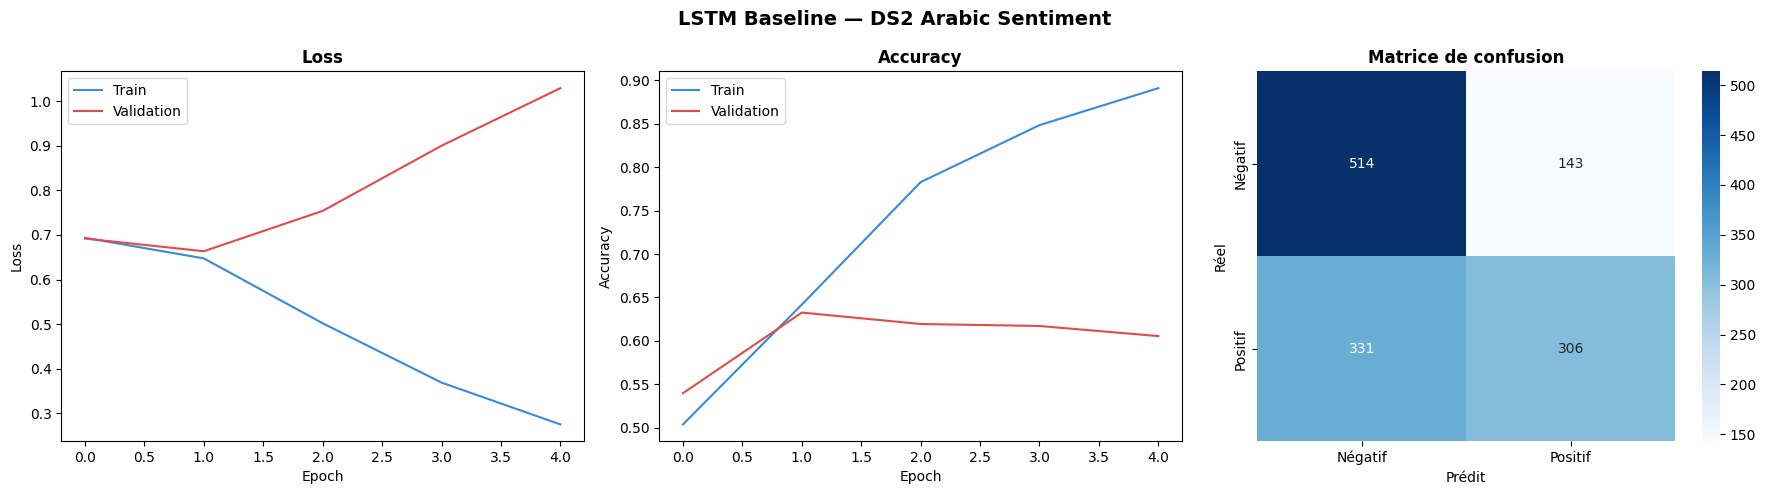

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Courbe Loss
axes[0].plot(history.history['loss'], label='Train', color='#378ADD')
axes[0].plot(history.history['val_loss'], label='Validation', color='#E24B4A')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Courbe Accuracy
axes[1].plot(history.history['accuracy'], label='Train', color='#378ADD')
axes[1].plot(history.history['val_accuracy'], label='Validation', color='#E24B4A')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'], ax=axes[2])
axes[2].set_title('Matrice de confusion', fontweight='bold')
axes[2].set_xlabel('Prédit')
axes[2].set_ylabel('Réel')

plt.suptitle('LSTM Baseline — DS2 Arabic Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sauvegarde des Résultats

In [14]:
results = {
    'methode'   : 'Baseline',
    'features'  : VOCAB_SIZE,
    'accuracy'  : round(accuracy, 4),
    'f1_macro'  : round(f1, 4),
    'precision' : round(precision, 4),
    'recall'    : round(recall, 4),
    'temps_s'   : round(training_time, 1)
}

pd.DataFrame([results]).to_csv(RESULTS_PATH + 'baseline_ds2.csv', index=False)
print(pd.DataFrame([results]).to_string(index=False))

 methode  features  accuracy  f1_macro  precision  recall  temps_s
Baseline     10000    0.6337     0.624     0.6449  0.6314     19.9



# Interprétation — LSTM Baseline DS2 Arabic Sentiment

## Performance Générale

| Métrique  | Valeur |
|-----------|--------|
| Accuracy  | 63.37% |
| F1 macro  | 62.40% |
| Precision | 64.49% |
| Recall    | 63.14% |
| Temps     | 19.9s  |
| Features  | 10,000 |

Le modèle baseline atteint une accuracy de **63.37%**, ce qui représente
une performance modeste mais attendue pour une configuration sans
sélection d'attributs.

## Analyse de l'Overfitting

Les courbes d'apprentissage révèlent un overfitting sévère :

- Train accuracy : **89%** vs Val accuracy : **60%** → gap de 29%
- Train loss : **0.27** (baisse) vs Val loss : **1.03** (monte)

L'Early Stopping s'est déclenché à l'Epoch 5, ce qui confirme que
le modèle mémorise les données d'entraînement au lieu d'apprendre
des patterns généralisables.

## Analyse de la Matrice de Confusion

| | Prédit Négatif | Prédit Positif |
|---|---|---|
| Réel Négatif | **514** ✅ | 143 ❌ |
| Réel Positif | **331** ❌ | 306 ✅ |

Le modèle présente un biais vers la classe **Négatif** :
- Taux de bonne classification Négatif : 78.2%
- Taux de bonne classification Positif : 48.0%

Les tweets positifs sont mal classés dans 51.9% des cas.

## Causes Identifiées

1. **Dataset limité** : seulement 8,622 tweets après nettoyage
2. **maxlen = 24** : séquences courtes → perte de contexte
3. **Bruit résiduel** : mots collés aux stopwords (و، يا...)
4. **Pas de feature selection** : 10,000 features dont beaucoup inutiles

## Perspectives

La feature selection (Mutual Information et Algorithme Génétique)
devrait réduire le bruit dans le vocabulaire et améliorer la
généralisation du modèle en se concentrant sur les features
les plus discriminantes.
"""

from IPython.display import Markdown
display(Markdown(interpretation))